# Reentrada

## Imports

In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta
from tsai.all import *
import os
import wandb
from fastai.callback.wandb import WandbCallback
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import MultiLabelBinarizer
from tsai.all import *

pd.set_option('display.max_columns', None) # Mostrar todas las columnas al imprimir df

## Visualizar datos

In [2]:
# Lectura de TIP.csv
df_tip = pd.read_csv('Datos/TIP.csv')
df_tip

,NORAD_CAT_ID,MSG_EPOCH,INSERT_EPOCH,DECAY_EPOCH,WINDOW,REV,DIRECTION,LAT,LON,INCL,NEXT_REPORT,ID,HIGH_INTEREST,OBJECT_NUMBER
0,25667,11/08/2025 5:02,11/08/2025 5:16,14/08/2025 19:48,1080,36936,ascending,1.7,40.2,4.3,72,55689,Y,25667
1,25667,12/08/2025 21:45,15/08/2025 22:41,14/08/2025 19:31,840,36934,ascending,-3.2,333.2,4.3,24,55709,Y,25667
2,25667,13/08/2025 20:55,15/08/2025 22:41,13/08/2025 16:24,1,36916,descending,-1.7,281.0,4.3,0,55719,Y,25667
3,63158,4/08/2025 20:33,4/08/2025 20:46,8/08/2025 20:30,1140,488,ascending,16.0,97.2,19.3,72,55611,N,63158
4,63158,8/08/2025 8:13,8/08/2025 8:26,8/08/2025 10:27,240,480,ascending,15.5,247.6,19.2,0,55624,N,63158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
321,42994,3/01/2025 19:02,3/01/2025 19:18,4/01/2025 1:26,120,39972,descending,-17.3,191.9,97.4,2,37514,N,42994
322,42994,3/01/2025 23:05,3/01/2025 23:18,4/01/2025 1:08,37,39972,descending,53.4,208.6,97.4,0,37521,N,42994
323,42994,4/01/2025 2:44,4/01/2025 3:28,4/01/2025 1:04,1,39972,descending,55.7,209.7,97.4,0,37525,N,42994
324,57804,3/01/2025 7:24,3/01/2025 7:38,3/01/2025 13:28,240,341,ascending,-1.1,15.2,29.8,2,37504,N,57804


In [3]:
# Lectura de TLE.csv
df_tle = pd.read_csv('Datos/TLE.csv')
print(f"Columnas: {df_tle.columns}")
df_tle.head(3)

Columnas: Index(['COMMENT', 'ORIGINATOR', 'NORAD_CAT_ID', 'OBJECT_NAME', 'OBJECT_TYPE',
       'CLASSIFICATION_TYPE', 'INTLDES', 'EPOCH', 'EPOCH_MICROSECONDS',
       'MEAN_MOTION', 'ECCENTRICITY', 'INCLINATION', 'RA_OF_ASC_NODE',
       'ARG_OF_PERICENTER', 'MEAN_ANOMALY', 'EPHEMERIS_TYPE', 'ELEMENT_SET_NO',
       'REV_AT_EPOCH', 'BSTAR', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT', 'FILE',
       'TLE_LINE0', 'TLE_LINE1', 'TLE_LINE2', 'OBJECT_ID', 'OBJECT_NUMBER',
       'SEMIMAJOR_AXIS', 'PERIOD', 'APOGEE', 'PERIGEE', 'DECAYED'],
      dtype='str')


,COMMENT,ORIGINATOR,NORAD_CAT_ID,OBJECT_NAME,OBJECT_TYPE,CLASSIFICATION_TYPE,INTLDES,EPOCH,EPOCH_MICROSECONDS,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,EPHEMERIS_TYPE,ELEMENT_SET_NO,REV_AT_EPOCH,BSTAR,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,FILE,TLE_LINE0,TLE_LINE1,TLE_LINE2,OBJECT_ID,OBJECT_NUMBER,SEMIMAJOR_AXIS,PERIOD,APOGEE,PERIGEE,DECAYED
0,GENERATED VIA SPACETRACK.ORG API,18 SPCS,25667,ARIANE 42P R/B,ROCKET BODY,U,99016B,2025-08-07 12:00:00,0,15.114824,0.055274,4.328200,335.538500,94.409400,222.89200,0,999,36776,0.000817,0.025283,-0.000028,4806722,0 ARIANE 42P R/B,1 25667U 99016B 25219.50000000 .02528315 -28160-4 81711-3 0 9994,2 25667 4.3282 335.5385 0552739 94.4094 222.8920 15.11482427367769,1999-016B,25667,6909.815,95.271,913.613,149.748,1
1,GENERATED VIA SPACETRACK.ORG API,18 SPCS,25667,ARIANE 42P R/B,ROCKET BODY,U,99016B,2025-08-07 12:00:00,0,15.114824,0.055274,4.328200,335.538500,94.409400,222.89200,0,999,36820,0.000817,0.025283,-0.000028,4806670,0 ARIANE 42P R/B,1 25667U 99016B 25219.50000000 .02528315 -28160-4 81711-3 0 9994,2 25667 4.3282 335.5385 0552739 94.4094 222.8920 15.11482427368209,1999-016B,25667,6909.815,95.271,913.613,149.748,1
2,GENERATED VIA SPACETRACK.ORG API,18 SPCS,25667,ARIANE 42P R/B,ROCKET BODY,U,99016B,2025-08-03 20:04:11,844480,14.773368,0.069171,4.330284,2.619863,40.630842,324.34104,0,999,36775,0.001352,0.031880,-0.000026,4806584,0 ARIANE 42P R/B,1 25667U 99016B 25215.83624820 .03188028 -26146-4 13522-2 0 9998,2 25667 4.3303 2.6199 0691709 40.6308 324.3410 14.77336804367759,1999-016B,25667,7015.880,97.473,1123.040,152.451,1


## Clasificadora de órbitas

In [4]:
def get_orbit_type(apogee, perigee):
    """
        Clasifica la órbita en base a su Apogeo y Perigeo (en km).
        - Input: Apogeo y Perigeo en km.
        - Output: Tipo de órbita y clase numérica.
    """
    if apogee < 2000:
        return 'LEO', 0  
    elif perigee < 2000 and apogee > 2000:
        return 'GTO', 1  # En realidad aplica para HEO y GTO, pero lo etiquetamos como GTO para simplificar
    elif perigee >= 2000 and apogee <= 35000:
        return 'MEO', 2
    elif perigee >= 35000:
        return 'GEO', 3
    else:
        return 'UNKNOWN', 4
    
# Fuente principal (ESA):
# - https://conference.sdo.esoc.esa.int/proceedings/sdc5/paper/15

# Otras:
# - https://www.esa.int/Enabling_Support/Space_Transportation/Types_of_orbits
# - https://eos.com/blog/types-of-satellites/

## Preprocesamiento

### Carga de datos

In [5]:
print("[1] Cargando datos")

LIMPIAR_COLUMNAS = True
WINDOW_SIZE = 7
DAYS_BEFORE_DECAY_SEARCH = 14

ruta_tip='Datos/TIP.csv'
ruta_tle='Datos/TLE.csv'

tip = pd.read_csv(ruta_tip)
tle = pd.read_csv(ruta_tle)

print(f"\t TLE: {tle.shape[0]} filas x {tle.shape[1]} columnas")
print(f"\t TIP: {tip.shape[0]} filas x {tip.shape[1]} columnas")
print(f"\n\t Columnas TLE: {tle.columns}")
print(f"\t Columnas TIP: {tip.columns}")

[1] Cargando datos
	 TLE: 2731 filas x 32 columnas
	 TIP: 326 filas x 14 columnas

	 Columnas TLE: Index(['COMMENT', 'ORIGINATOR', 'NORAD_CAT_ID', 'OBJECT_NAME', 'OBJECT_TYPE',
       'CLASSIFICATION_TYPE', 'INTLDES', 'EPOCH', 'EPOCH_MICROSECONDS',
       'MEAN_MOTION', 'ECCENTRICITY', 'INCLINATION', 'RA_OF_ASC_NODE',
       'ARG_OF_PERICENTER', 'MEAN_ANOMALY', 'EPHEMERIS_TYPE', 'ELEMENT_SET_NO',
       'REV_AT_EPOCH', 'BSTAR', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT', 'FILE',
       'TLE_LINE0', 'TLE_LINE1', 'TLE_LINE2', 'OBJECT_ID', 'OBJECT_NUMBER',
       'SEMIMAJOR_AXIS', 'PERIOD', 'APOGEE', 'PERIGEE', 'DECAYED'],
      dtype='str')
	 Columnas TIP: Index(['NORAD_CAT_ID', 'MSG_EPOCH', 'INSERT_EPOCH', 'DECAY_EPOCH', 'WINDOW',
       'REV', 'DIRECTION', 'LAT', 'LON', 'INCL', 'NEXT_REPORT', 'ID',
       'HIGH_INTEREST', 'OBJECT_NUMBER'],
      dtype='str')


### Eliminación de TLEs duplicados

Eliminamos filas duplicadas de TLE para el mismo objeto (NORAD_CAT_ID) y momento exacto (EPOCH). Nos quedamos siempre con la versión que tiene el número de FILE más alto

In [6]:
print("[2] Eliminando TLEs duplicados")
total_inicial = len(tle)

if not pd.api.types.is_datetime64_any_dtype(tle['EPOCH']):
    tle['EPOCH'] = pd.to_datetime(tle['EPOCH'])
    
tle = tle.sort_values(['NORAD_CAT_ID', 'EPOCH', 'FILE'])     # Ordenamos por objeto, fecha y FILE (de menor a mayor)
tle = tle.drop_duplicates(subset=['NORAD_CAT_ID', 'EPOCH'], keep='last')     # Eliminamos duplicados

tle = tle.reset_index(drop=True)

eliminadas = total_inicial - len(tle)

print(f"\t TLE sin duplicados: {tle.shape[0]} filas x {tle.shape[1]} columnas")
print(f"\t\t TLEs originales: {total_inicial}")
print(f"\t\t TLEs eliminados: {eliminadas}")
print(f"\t\t TLEs resultantes: {len(tle)}")


[2] Eliminando TLEs duplicados
	 TLE sin duplicados: 2081 filas x 32 columnas
		 TLEs originales: 2731
		 TLEs eliminados: 650
		 TLEs resultantes: 2081


### Selección de columnas

In [7]:
# Columnas finales del dataset de ventanas
# columns = [
#     'SEQUENCE_ID', 'NORAD_CAT_ID', 'EPOCH', 'ANCHOR_EPOCH', 'IS_PADDING',
#     'ORBIT_CLASS',
#     'MEAN_MOTION', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT',
#     'ECCENTRICITY', 'INCLINATION', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY',
#     'BSTAR', 'LOG_BSTAR', 'REV_AT_EPOCH', 'SEMIMAJOR_AXIS', 'PERIOD', 'APOGEE', 'PERIGEE',
#     'TARGET_Y_MINUTES', 'TARGET_DAY_CLASS', 'TARGET_HOUR_CLASS', 'TARGET_MINUTE_CLASS'
#  ]

# Columnas de TLE necesarias para generar las ventanas


In [8]:
print("[3] Filtrando columnas TLE")
print(f"\t TLE antes de filtrar: {tle.shape[0]} filas x {tle.shape[1]} columnas")
print(f"\t Columnas TLE antes de filtrar: {tle.columns.to_list()}")

tle_base_columns = [
    'NORAD_CAT_ID', 'EPOCH',
    'MEAN_MOTION', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT',
    'ECCENTRICITY', 'INCLINATION', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY',
    'BSTAR', 'REV_AT_EPOCH', 'SEMIMAJOR_AXIS', 'PERIOD', 'APOGEE', 'PERIGEE'
 ]

tle = tle[tle_base_columns].copy()

print(f"\n\t TLE filtrado antes del sliding window: {tle.shape[0]} filas x {tle.shape[1]} columnas")
print(f"\t Columnas TLE antes de filtrar: {tle.columns.to_list()}")

[3] Filtrando columnas TLE
	 TLE antes de filtrar: 2081 filas x 32 columnas
	 Columnas TLE antes de filtrar: ['COMMENT', 'ORIGINATOR', 'NORAD_CAT_ID', 'OBJECT_NAME', 'OBJECT_TYPE', 'CLASSIFICATION_TYPE', 'INTLDES', 'EPOCH', 'EPOCH_MICROSECONDS', 'MEAN_MOTION', 'ECCENTRICITY', 'INCLINATION', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY', 'EPHEMERIS_TYPE', 'ELEMENT_SET_NO', 'REV_AT_EPOCH', 'BSTAR', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT', 'FILE', 'TLE_LINE0', 'TLE_LINE1', 'TLE_LINE2', 'OBJECT_ID', 'OBJECT_NUMBER', 'SEMIMAJOR_AXIS', 'PERIOD', 'APOGEE', 'PERIGEE', 'DECAYED']

	 TLE filtrado antes del sliding window: 2081 filas x 16 columnas
	 Columnas TLE antes de filtrar: ['NORAD_CAT_ID', 'EPOCH', 'MEAN_MOTION', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT', 'ECCENTRICITY', 'INCLINATION', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY', 'BSTAR', 'REV_AT_EPOCH', 'SEMIMAJOR_AXIS', 'PERIOD', 'APOGEE', 'PERIGEE']


### Sliding window

En este paso se genera `windows`, una lista de dataframes donde cada dataframe representa una ventana temporal de TLEs para un mismo objeto.  

Primero, para cada objeto se toma su último TIP y se buscan TLEs ancla dentro del intervalo **[DECAY_EPOCH - DAYS_BEFORE_DECAY_SEARCH, DECAY_EPOCH - 1 día]**.   Después, para cada ancla se construye la ventana tomando **todos** los TLEs del objeto cuyo `EPOCH` esté entre **[anchor_epoch - WINDOW_SIZE días, anchor_epoch]** (incluyendo el ancla). Por tanto, el número de TLEs por ventana puede variar.

In [9]:
print("[4] Sliding window")

# Formateo de fechas
tip['MSG_EPOCH'] = pd.to_datetime(tip['MSG_EPOCH'], dayfirst=True)
tip['DECAY_EPOCH'] = pd.to_datetime(tip['DECAY_EPOCH'], dayfirst=True)
tle['EPOCH'] = pd.to_datetime(tle['EPOCH'])

tip = tip.sort_values(['NORAD_CAT_ID', 'MSG_EPOCH']) # Ordenamos por objeto y fecha
last_tips = tip.groupby('NORAD_CAT_ID').last().reset_index() # Nos quedamos con el último TIP de cada objeto (decay más exacto)

windows = []
seq_id = 1

for index, row in last_tips.iterrows(): # Iteramos por cada objeto usando su último TIP
    obj_id = row['NORAD_CAT_ID'] # Seleccionamos el ID del objeto
    ground_truth_decay = row['DECAY_EPOCH']
    
    obj_tles = tle[tle['NORAD_CAT_ID'] == obj_id].sort_values('EPOCH') # Filtramos TLEs de este objeto y los ordenamos por fecha]

    if obj_tles.empty: continue
    
    primer_tle = obj_tles.iloc[0]
    _, orbit_code = get_orbit_type(primer_tle['APOGEE'], primer_tle['PERIGEE'])
    
    # Inicio y fin de búsqueda para cabezas de ventana (14 a 1 días antes del decay)
    inicio_busqueda = ground_truth_decay - timedelta(days=DAYS_BEFORE_DECAY_SEARCH)
    fin_busqueda = ground_truth_decay - timedelta(days=1)
    
    anclas = obj_tles[(obj_tles['EPOCH'] >= inicio_busqueda) & (obj_tles['EPOCH'] <= fin_busqueda)]
    
    for _, anchor_tle in anclas.iterrows():
        anchor_epoch = anchor_tle['EPOCH']
        
        # --- VENTANA DE TIEMPO DEFINIDA (1 SEMANA) ---
        start_window = anchor_epoch - timedelta(days=WINDOW_SIZE)
        window_tles = obj_tles[(obj_tles['EPOCH'] >= start_window) & (obj_tles['EPOCH'] <= anchor_epoch)].copy()
        
        if window_tles.empty: continue
        
        y_target_minutes = (ground_truth_decay - anchor_epoch).total_seconds() / 60.0
        
        window_tles['SEQUENCE_ID'] = seq_id # ID global de ventana
        window_tles['LOG_BSTAR'] = np.log10(window_tles['BSTAR'].abs().clip(lower=1e-9)) # Transformación logarítmica de B* para mejorar la distribución
        
        window_tles['ANCHOR_EPOCH'] = anchor_epoch
        window_tles['IS_PADDING'] = 0 
        # window_tles['ORBIT_TYPE'] = orbit_name
        window_tles['ORBIT_CLASS'] = orbit_code

        # Etiqueta continua (minutos hasta el decay)
        window_tles['TARGET_Y_MINUTES'] = y_target_minutes 

        # Etiquetas discretas (clases)
        window_tles['TARGET_DAY_CLASS'] = int(y_target_minutes // (24 * 60))
        window_tles['TARGET_HOUR_CLASS'] = int((y_target_minutes % (24 * 60)) // 60)
        window_tles['TARGET_MINUTE_CLASS'] = int(y_target_minutes % 60)
        
        windows.append(window_tles)
        seq_id += 1

###################################################################################
################################# RESUMEN #########################################
print(f"Total de ventanas generadas: {len(windows)}")

# Tamaño interno de cada ventana (nº de TLEs por ventana)
tam_ventanas = pd.Series([len(w) for w in windows], name='TLES_POR_VENTANA')
print(f"\t Máximo TLEs por ventana: {tam_ventanas.max()}")
print(f"\t Media TLEs por ventana: {tam_ventanas.mean():.2f}")
print(f"\t Mediana TLEs por ventana: {tam_ventanas.median():.0f}")

# Cuántas ventanas tiene cada objeto
obj_ids = [int(w['NORAD_CAT_ID'].iloc[0]) for w in windows if len(w) > 0]
windows_por_objeto = pd.Series(obj_ids, name='NORAD_CAT_ID').value_counts().sort_values(ascending=False)

print(f"\n Objetos únicos con ventanas: {windows_por_objeto.size}")
print(f"\t Máximo ventanas por objeto: {windows_por_objeto.max()}")
print(f"\t Media ventanas por objeto: {windows_por_objeto.mean():.2f}")
print(f"\t Mediana ventanas por objeto: {windows_por_objeto.median():.0f}")

# Ejemplo de primera ventana
print(f"\nEjemplo de primera ventana:")
windows[0].head(5)


################### DESCOMENTAR PARA VER LAS VENTANAS POR OBJETO ##################
# df_windows_por_objeto = windows_por_objeto.rename_axis('NORAD_CAT_ID').reset_index(name='NUM_WINDOWS')
# df_windows_por_objeto.head(10)

[4] Sliding window
Total de ventanas generadas: 815
	 Máximo TLEs por ventana: 34
	 Media TLEs por ventana: 11.93
	 Mediana TLEs por ventana: 11

 Objetos únicos con ventanas: 52
	 Máximo ventanas por objeto: 45
	 Media ventanas por objeto: 15.67
	 Mediana ventanas por objeto: 16

Ejemplo de primera ventana:


,NORAD_CAT_ID,EPOCH,MEAN_MOTION,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,BSTAR,REV_AT_EPOCH,SEMIMAJOR_AXIS,PERIOD,APOGEE,PERIGEE,SEQUENCE_ID,LOG_BSTAR,ANCHOR_EPOCH,IS_PADDING,ORBIT_CLASS,TARGET_Y_MINUTES,TARGET_DAY_CLASS,TARGET_HOUR_CLASS,TARGET_MINUTE_CLASS
5,10723,2025-02-01 10:56:36,14.089536,0.023737,-0.000005,0.097488,29.2321,51.2142,324.9714,29.0347,0.001535,53208,7241.092,102.204,1568.873,157.041,1,-2.813835,2025-02-08 02:31:53,0,0,19614.116667,13,14,54
6,10723,2025-02-02 09:01:07,14.135715,0.025668,-0.000004,0.095567,29.2297,45.9563,333.4195,22.0291,0.001613,53221,7225.313,101.870,1537.678,156.678,1,-2.792339,2025-02-08 02:31:53,0,0,19614.116667,13,14,54
7,10723,2025-02-03 01:56:59,14.172649,0.026521,-0.000004,0.094032,29.2287,41.8975,339.9372,16.6482,0.001628,53231,7212.754,101.604,1512.852,156.387,1,-2.788212,2025-02-08 02:31:53,0,0,19614.116667,13,14,54
8,10723,2025-02-03 10:23:55,14.190768,0.026364,-0.000004,0.093265,29.2284,39.8627,343.1965,13.9594,0.001608,53236,7206.614,101.474,1500.605,156.352,1,-2.793687,2025-02-08 02:31:53,0,0,19614.116667,13,14,54
9,10723,2025-02-04 03:15:50,14.227298,0.026261,-0.000004,0.091751,29.2283,35.7844,349.7204,8.5731,0.001564,53246,7194.273,101.214,1476.219,156.056,1,-2.805624,2025-02-08 02:31:53,0,0,19614.116667,13,14,54


### Rellenar con padding

Aquí, aplicamos padding y seteamos a esas filas el flag a 1 (`IS_PADDING = 1`),  para igualar todas las ventanas a una longitud fija común (`max_seq_length`), que es la de la ventana más grande.

In [10]:
print("[5] Rellenando con padding")

# Longitud original por ventana (antes de padding)
original_lengths = pd.Series([len(v) for v in windows], name='LEN_ORIGINAL')
max_seq_length = int(original_lengths.max())
print(f"La ventana más grande tiene {max_seq_length} TLEs. Todas las ventanas se rellenarán hasta este tamaño.")

windows_processed = []
num_windows_padded = 0
total_padding_rows = 0

for window_tles in windows:
    faltantes = max_seq_length - len(window_tles)

    if faltantes > 0:
        num_windows_padded += 1
        total_padding_rows += faltantes

        pad_df = pd.DataFrame(index=range(faltantes), columns=window_tles.columns)

        # Metadatos que deben conservarse en las filas de relleno
        pad_df['SEQUENCE_ID'] = window_tles.iloc[0]['SEQUENCE_ID']
        pad_df['NORAD_CAT_ID'] = window_tles.iloc[0]['NORAD_CAT_ID']
        pad_df['ANCHOR_EPOCH'] = window_tles.iloc[0]['ANCHOR_EPOCH']
        pad_df['EPOCH'] = pd.NaT
        # pad_df['ORBIT_TYPE'] = window_tles.iloc[0]['ORBIT_TYPE']
        pad_df['ORBIT_CLASS'] = window_tles.iloc[0]['ORBIT_CLASS']
        pad_df['TARGET_Y_MINUTES'] = window_tles.iloc[0]['TARGET_Y_MINUTES']
        pad_df['TARGET_DAY_CLASS'] = window_tles.iloc[0]['TARGET_DAY_CLASS']
        pad_df['TARGET_HOUR_CLASS'] = window_tles.iloc[0]['TARGET_HOUR_CLASS']
        pad_df['TARGET_MINUTE_CLASS'] = window_tles.iloc[0]['TARGET_MINUTE_CLASS']
        pad_df['IS_PADDING'] = 1

        # El resto de columnas numéricas se rellenan con 0
        numeric_cols = window_tles.select_dtypes(include=[np.number]).columns
        pad_df[numeric_cols] = pad_df[numeric_cols].fillna(0)

        # Pre-padding (filas de relleno arriba, datos reales abajo)
        window_tles = pd.concat([pad_df, window_tles], ignore_index=True)

    windows_processed.append(window_tles)

# Juntar todo el dataset
df_final = pd.concat(windows_processed, ignore_index=True)

# Longitud procesada por ventana (después de padding)
processed_lengths = pd.Series([len(w) for w in windows_processed], name='LEN_PROCESADA')

# Resumen de filas y shape antes/después del padding
filas_antes_padding = int(original_lengths.sum())
columnas_dataset = windows[0].shape[1] if len(windows) > 0 else 0
shape_antes_padding = (filas_antes_padding, columnas_dataset)
shape_despues_padding = df_final.shape


########## RESUMEN PADDING ##########
print(f"Ventanas totales: {len(windows)}")
print(f"Ventanas con padding: {num_windows_padded}")
print(f"Ventanas sin padding: {len(windows) - num_windows_padded}")
print(f"Filas de padding añadidas: {total_padding_rows}")

print("\nShape del dataset ANTES del padding:")
print(f"\t {shape_antes_padding} -> {filas_antes_padding} filas x {columnas_dataset} columnas")

print("\nShape del dataset DESPUÉS del padding:")
print(f"\t {shape_despues_padding} -> {shape_despues_padding[0]} filas x {shape_despues_padding[1]} columnas")

print("\nCálculo de filas esperadas con tamaño fijo:")
print(f"\t {max_seq_length} TLEs por {len(windows)} ventanas = {len(windows) * max_seq_length} filas")

print("\nLongitudes ANTES del padding:")
print(f"\t Mínima: {int(original_lengths.min())}")
print(f"\t Media: {original_lengths.mean():.2f}")
print(f"\t Mediana: {original_lengths.median():.0f}")
print(f"\t Máxima: {int(original_lengths.max())}")

print("\nLongitudes DESPUÉS del padding:")
print(f"\t Mínima: {int(processed_lengths.min())}")
print(f"\t Media: {processed_lengths.mean():.2f}")
print(f"\t Mediana: {processed_lengths.median():.0f}")
print(f"\t Máxima: {int(processed_lengths.max())}")

all_fixed = (processed_lengths.nunique() == 1 and int(processed_lengths.iloc[0]) == max_seq_length)
print(f"\n¿Todas las ventanas quedaron con tamaño fijo ({max_seq_length})?: {all_fixed}")
print(f"Filas totales esperadas: {len(windows) * max_seq_length}")
print(f"Filas totales reales en df_final: {len(df_final)}")

[5] Rellenando con padding
La ventana más grande tiene 34 TLEs. Todas las ventanas se rellenarán hasta este tamaño.
Ventanas totales: 815
Ventanas con padding: 814
Ventanas sin padding: 1
Filas de padding añadidas: 17983

Shape del dataset ANTES del padding:
	 (9727, 25) -> 9727 filas x 25 columnas

Shape del dataset DESPUÉS del padding:
	 (27710, 25) -> 27710 filas x 25 columnas

Cálculo de filas esperadas con tamaño fijo:
	 34 TLEs por 815 ventanas = 27710 filas

Longitudes ANTES del padding:
	 Mínima: 1
	 Media: 11.93
	 Mediana: 11
	 Máxima: 34

Longitudes DESPUÉS del padding:
	 Mínima: 34
	 Media: 34.00
	 Mediana: 34
	 Máxima: 34

¿Todas las ventanas quedaron con tamaño fijo (34)?: True
Filas totales esperadas: 27710
Filas totales reales en df_final: 27710


In [11]:
############### EXPORTAR A CSV ###############
# Exportar a CSV
ruta_salida = 'datasets/Dataset_TFM_Limpio.csv'
df_final.to_csv(ruta_salida, index=False, sep=';', decimal=',')

print(f"Total de secuencias de entrenamiento (ventanas): {len(windows)}")
print(f"Tamaño fijo de la ventana: {max_seq_length}")
print(f"Filas totales en el CSV: {len(df_final)} ({len(windows)} * {max_seq_length})")
print(f"Guardado en: {ruta_salida}")

Total de secuencias de entrenamiento (ventanas): 815
Tamaño fijo de la ventana: 34
Filas totales en el CSV: 27710 (815 * 34)
Guardado en: datasets/Dataset_TFM_Limpio.csv


## Transformar a tensor

In [12]:
# # Ejemplo tsai
# user = np.array([1,2]).repeat(4).reshape(-1,1)
# val = np.random.rand(8, 3)
# data = np.concatenate([user, val], axis=-1)
# df = pd.DataFrame(data, columns=['user', 'x1', 'x2', 'x3'])
# test_eq(df2np3d(df, ['user'], ['x1', 'x2', 'x3']).shape, (2, 3, 4))

In [13]:
print("[6] TRANSFORMACIÓN A TENSOR 3D (tsai)")

# 1. Definimos las columnas físicas
feature_cols = [
    'IS_PADDING', 'ORBIT_CLASS', 
    'MEAN_MOTION', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT', 
    'ECCENTRICITY', 'INCLINATION', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY', 
    'LOG_BSTAR', 'REV_AT_EPOCH', 'SEMIMAJOR_AXIS', 'PERIOD', 'APOGEE', 'PERIGEE'
]

# 2. Forzamos columnas físicas a numérico para evitar dtype=object en X
df_proc = df_final.copy()
df_proc[feature_cols] = df_proc[feature_cols].apply(pd.to_numeric, errors='coerce') # Convertimos columnas a numérico, forzando errores a NaN
df_proc[feature_cols] = df_proc[feature_cols].fillna(0).astype(np.float32) # Rellenamos NaNs con 0 y convertimos a float32 para eficiencia

# 3. Ordenamos y creamos las etiquetas (y) Multi-label
df_sorted = df_proc.sort_values(["SEQUENCE_ID", "EPOCH"], na_position='first') # El na_position='first' asegura que los TLEs de padding (con EPOCH NaT) queden al inicio de la ventana, antes de los TLEs reales
sequence_metadata = df_sorted.groupby("SEQUENCE_ID").first().reset_index()

dias_ordenados = [f"Dia_{i}" for i in range(1, 14)]  # Del 1 al 13
horas_ordenadas = [f"Hora_{i}" for i in range(24)]   # Del 0 al 23
minutos_ordenados = [f"Min_{i}" for i in range(60)]  # Del 0 al 59

mis_clases_ordenadas = dias_ordenados + horas_ordenadas + minutos_ordenados

print(f"Numero de clases: {len(mis_clases_ordenadas)}")

mlb = MultiLabelBinarizer(classes=mis_clases_ordenadas) # Para convertir las etiquetas de clase múltiple en formato binarizado (one-hot encoding)
etiquetas = sequence_metadata.apply(lambda r: [f"Dia_{int(r.TARGET_DAY_CLASS)}", f"Hora_{int(r.TARGET_HOUR_CLASS)}", f"Min_{int(r.TARGET_MINUTE_CLASS)}"], axis=1) # axis 1 es para aplicar la función a cada fila
y = mlb.fit_transform(etiquetas)

# 4. Split seguro (Sin mezclar objetos)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, valid_idx = next(gss.split(sequence_metadata['SEQUENCE_ID'], groups=sequence_metadata['NORAD_CAT_ID'])) # el next() es porque gss.split devuelve un generador, y con next() obtenemos los índices del split

# 5. Transformar a X (Tensor 3D)
X = df2np3d(df_sorted, groupby='SEQUENCE_ID', data_cols=feature_cols).astype(np.float32)

# 6. Combine split data
X_final, y_final, splits = combine_split_data([X[train_idx], X[valid_idx]], [y[train_idx], y[valid_idx]])

print(f"✅ Listo. Forma de X: {X_final.shape} | Clases únicas: {len(mlb.classes_)}")
#return X_final, y_final, splits, mlb.classes_

[6] TRANSFORMACIÓN A TENSOR 3D (tsai)
Numero de clases: 97
✅ Listo. Forma de X: (815, 16, 34) | Clases únicas: 97


In [14]:
print("[6.1] INSPECCIÓN DEL PROCESO + MULTILABELBINARIZER")
import numpy as np

required_cols = [
    'SEQUENCE_ID', 'NORAD_CAT_ID', 'EPOCH',
    'TARGET_DAY_CLASS', 'TARGET_HOUR_CLASS', 'TARGET_MINUTE_CLASS',
    'IS_PADDING', 'ORBIT_CLASS',
    'MEAN_MOTION', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT',
    'ECCENTRICITY', 'INCLINATION', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY',
    'LOG_BSTAR', 'REV_AT_EPOCH', 'SEMIMAJOR_AXIS', 'PERIOD', 'APOGEE', 'PERIGEE'
]

# Selección robusta de dataframe fuente
df_candidates = []
if 'df' in globals() and isinstance(df_final, pd.DataFrame):
    df_candidates.append(('df', df_final))
if 'df_final' in globals() and isinstance(df_final, pd.DataFrame):
    df_candidates.append(('df_final', df_final))

df_source_name = None
df_source = None
for name, candidate in df_candidates:
    if all(c in candidate.columns for c in required_cols):
        df_source_name = name
        df_source = candidate
        break

if df_source is None:
    print("❌ No encuentro un DataFrame válido con las columnas esperadas.")
    print("Ejecuta antes la celda de preprocesado/padding para generar 'df_final' o asigna el resultado a 'df'.")
    print("Pista: ahora mismo 'df' puede ser el ejemplo sintético de tsai (user, x1, x2, x3).")
else:
    print(f"✅ Usando {df_source_name} como fuente para la inspección.")

    feature_cols = [
        'IS_PADDING', 'ORBIT_CLASS',
        'MEAN_MOTION', 'MEAN_MOTION_DOT', 'MEAN_MOTION_DDOT',
        'ECCENTRICITY', 'INCLINATION', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY',
        'LOG_BSTAR', 'REV_AT_EPOCH', 'SEMIMAJOR_AXIS', 'PERIOD', 'APOGEE', 'PERIGEE'
    ]

    # 1) Limpieza/typing
    df_proc_demo = df_source.copy()
    df_proc_demo[feature_cols] = df_proc_demo[feature_cols].apply(pd.to_numeric, errors='coerce')
    df_proc_demo[feature_cols] = df_proc_demo[feature_cols].fillna(0).astype(np.float32)

    # 2) Orden y agregación por secuencia
    df_sorted_demo = df_proc_demo.sort_values(["SEQUENCE_ID", "EPOCH"], na_position='first')
    sequence_metadata_demo = df_sorted_demo.groupby("SEQUENCE_ID").first().reset_index()

    # 3) Construcción de etiquetas multilabel
    etiquetas_demo = sequence_metadata_demo.apply(
        lambda r: [
            f"Dia_{int(r.TARGET_DAY_CLASS)}",
            f"Hora_{int(r.TARGET_HOUR_CLASS)}",
            f"Min_{int(r.TARGET_MINUTE_CLASS)}"
        ],
        axis=1
    )

    mlb_demo = MultiLabelBinarizer()
    y_demo = mlb_demo.fit_transform(etiquetas_demo).astype(np.float32)

    print("\n--- RESUMEN DE TRANSFORMACIÓN ---")
    print(f"df fuente:                  {df_source.shape}")
    print(f"df procesado (tipado):      {df_proc_demo.shape}")
    print(f"df ordenado:                {df_sorted_demo.shape}")
    print(f"metadata por secuencia:     {sequence_metadata_demo.shape}")
    print(f"y one-hot multilabel:       {y_demo.shape}")
    print(f"nº clases MLB:              {len(mlb_demo.classes_)}")

    print("\nOrden interno de clases de MultiLabelBinarizer:")
    print(list(mlb_demo.classes_))

    print("\nEjemplos de inspección (1-2 secuencias):")
    num_examples = min(2, len(sequence_metadata_demo))
    for i in range(num_examples):
        seq_id = int(sequence_metadata_demo.iloc[i]['SEQUENCE_ID'])
        etiquetas_esperadas = etiquetas_demo.iloc[i]
        active_idx = np.where(y_demo[i] == 1)[0].tolist()
        active_classes = [mlb_demo.classes_[j] for j in active_idx]

        print(f"\nSecuencia {seq_id}")
        print(f"- Etiquetas esperadas: {etiquetas_esperadas}")
        print(f"- Índices activos one-hot: {active_idx}")
        print(f"- Clases activadas MLB: {active_classes}")
        print(f"- ¿Coinciden conjuntos?: {set(etiquetas_esperadas) == set(active_classes)}")

    print("\nNota importante sobre MLB:")
    print("- MultiLabelBinarizer ordena clases globalmente (normalmente orden alfabético/lexicográfico).")
    print("- Por eso, la posición de una clase en el one-hot puede no coincidir con ejemplos manuales si usan otro orden.")
    print("- Si quieres orden humano (p.ej. Dia_0..Dia_30), conviene definir classes=... manualmente o usar zero-padding.")

[6.1] INSPECCIÓN DEL PROCESO + MULTILABELBINARIZER
✅ Usando df_final como fuente para la inspección.

--- RESUMEN DE TRANSFORMACIÓN ---
df fuente:                  (27710, 25)
df procesado (tipado):      (27710, 25)
df ordenado:                (27710, 25)
metadata por secuencia:     (815, 25)
y one-hot multilabel:       (815, 97)
nº clases MLB:              97

Orden interno de clases de MultiLabelBinarizer:
['Dia_1', 'Dia_10', 'Dia_11', 'Dia_12', 'Dia_13', 'Dia_2', 'Dia_3', 'Dia_4', 'Dia_5', 'Dia_6', 'Dia_7', 'Dia_8', 'Dia_9', 'Hora_0', 'Hora_1', 'Hora_10', 'Hora_11', 'Hora_12', 'Hora_13', 'Hora_14', 'Hora_15', 'Hora_16', 'Hora_17', 'Hora_18', 'Hora_19', 'Hora_2', 'Hora_20', 'Hora_21', 'Hora_22', 'Hora_23', 'Hora_3', 'Hora_4', 'Hora_5', 'Hora_6', 'Hora_7', 'Hora_8', 'Hora_9', 'Min_0', 'Min_1', 'Min_10', 'Min_11', 'Min_12', 'Min_13', 'Min_14', 'Min_15', 'Min_16', 'Min_17', 'Min_18', 'Min_19', 'Min_2', 'Min_20', 'Min_21', 'Min_22', 'Min_23', 'Min_24', 'Min_25', 'Min_26', 'Min_27', 'Min_

In [15]:
print(list(mlb.classes_))

['Dia_1', 'Dia_2', 'Dia_3', 'Dia_4', 'Dia_5', 'Dia_6', 'Dia_7', 'Dia_8', 'Dia_9', 'Dia_10', 'Dia_11', 'Dia_12', 'Dia_13', 'Hora_0', 'Hora_1', 'Hora_2', 'Hora_3', 'Hora_4', 'Hora_5', 'Hora_6', 'Hora_7', 'Hora_8', 'Hora_9', 'Hora_10', 'Hora_11', 'Hora_12', 'Hora_13', 'Hora_14', 'Hora_15', 'Hora_16', 'Hora_17', 'Hora_18', 'Hora_19', 'Hora_20', 'Hora_21', 'Hora_22', 'Hora_23', 'Min_0', 'Min_1', 'Min_2', 'Min_3', 'Min_4', 'Min_5', 'Min_6', 'Min_7', 'Min_8', 'Min_9', 'Min_10', 'Min_11', 'Min_12', 'Min_13', 'Min_14', 'Min_15', 'Min_16', 'Min_17', 'Min_18', 'Min_19', 'Min_20', 'Min_21', 'Min_22', 'Min_23', 'Min_24', 'Min_25', 'Min_26', 'Min_27', 'Min_28', 'Min_29', 'Min_30', 'Min_31', 'Min_32', 'Min_33', 'Min_34', 'Min_35', 'Min_36', 'Min_37', 'Min_38', 'Min_39', 'Min_40', 'Min_41', 'Min_42', 'Min_43', 'Min_44', 'Min_45', 'Min_46', 'Min_47', 'Min_48', 'Min_49', 'Min_50', 'Min_51', 'Min_52', 'Min_53', 'Min_54', 'Min_55', 'Min_56', 'Min_57', 'Min_58', 'Min_59']


In [16]:
df_final.head(2)

,NORAD_CAT_ID,EPOCH,MEAN_MOTION,MEAN_MOTION_DOT,MEAN_MOTION_DDOT,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,BSTAR,REV_AT_EPOCH,SEMIMAJOR_AXIS,PERIOD,APOGEE,PERIGEE,SEQUENCE_ID,LOG_BSTAR,ANCHOR_EPOCH,IS_PADDING,ORBIT_CLASS,TARGET_Y_MINUTES,TARGET_DAY_CLASS,TARGET_HOUR_CLASS,TARGET_MINUTE_CLASS
0,10723,NaT,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,2025-02-08 02:31:53,1,0,19614.116667,13,14,54
1,10723,NaT,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,2025-02-08 02:31:53,1,0,19614.116667,13,14,54


In [17]:
y[0]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0])

In [18]:
# learn.dls.train.dataset[0][0].show()

In [19]:
import torch

class MAE_Horas:
    def __init__(self, num_dias, num_horas):
        self.num_dias = num_dias
        self.num_horas = num_horas
        self.__name__ = "mae_horas"
        
    def __call__(self, preds, targets):
        idx_horas = self.num_dias
        idx_mins = self.num_dias + self.num_horas
        
        p_dias = preds[:, :idx_horas].argmax(dim=1).float()
        p_horas = preds[:, idx_horas:idx_mins].argmax(dim=1).float()
        p_mins = preds[:, idx_mins:].argmax(dim=1).float()
        
        t_dias = targets[:, :idx_horas].argmax(dim=1).float()
        t_horas = targets[:, idx_horas:idx_mins].argmax(dim=1).float()
        t_mins = targets[:, idx_mins:].argmax(dim=1).float()
        
        p_total = (p_dias * 24.0) + p_horas + (p_mins / 60.0)
        t_total = (t_dias * 24.0) + t_horas + (t_mins / 60.0)
        
        mae = torch.abs(p_total - t_total).mean()
        return mae

class MAPE:
    def __init__(self, num_dias, num_horas, eps_horas=1.0 / 60.0):
        self.num_dias = num_dias
        self.num_horas = num_horas
        self.eps_horas = eps_horas
        self.__name__ = "mape"
        
    def __call__(self, preds, targets):
        idx_horas = self.num_dias
        idx_mins = self.num_dias + self.num_horas
        
        p_dias = preds[:, :idx_horas].argmax(dim=1).float() # Con argmax buscamos el índice más alto (mayor probab)
        p_horas = preds[:, idx_horas:idx_mins].argmax(dim=1).float()
        p_mins = preds[:, idx_mins:].argmax(dim=1).float()
        
        t_dias = targets[:, :idx_horas].argmax(dim=1).float()
        t_horas = targets[:, idx_horas:idx_mins].argmax(dim=1).float()
        t_mins = targets[:, idx_mins:].argmax(dim=1).float()
        
        p_total = (p_dias * 24.0) + p_horas + (p_mins / 60.0)
        t_total = (t_dias * 24.0) + t_horas + (t_mins / 60.0)
        
        denom = torch.clamp(torch.abs(t_total), min=self.eps_horas) # El clamp con el min=1/60 lo hacemos por si acaso fuera 0 el denominador y que no pete
        mape = (torch.abs(p_total - t_total) / denom).mean() * 100.0
        return mape

In [20]:
class HierarchicalLoss(nn.Module):
    def __init__(self, num_dias, num_horas, num_minutos, peso_dia=10.0, peso_hora=5.0, peso_min=1.0):
        super().__init__()
        self.num_dias = num_dias
        self.num_horas = num_horas
        self.num_minutos = num_minutos
        
        # Asignación de la gravedad del error (pesos)
        self.peso_dia = peso_dia
        self.peso_hora = peso_hora
        self.peso_min = peso_min
        
        # Usamos la pérdida BCE nativa de fastai para calcular las partes
        self.bce = BCEWithLogitsLossFlat()
        
    def forward(self, preds, targets):
        idx_horas = self.num_dias
        idx_mins = self.num_dias + self.num_horas
        
        # 1. Cortamos los tensores de predicciones
        preds_dias = preds[:, :idx_horas]
        preds_horas = preds[:, idx_horas:idx_mins]
        preds_mins = preds[:, idx_mins:]
        
        # 2. Cortamos los tensores de los targets reales
        targets_dias = targets[:, :idx_horas]
        targets_horas = targets[:, idx_horas:idx_mins]
        targets_mins = targets[:, idx_mins:]
        
        # 3. Calculamos la pérdida de cada bloque por separado
        loss_dias = self.bce(preds_dias, targets_dias)
        loss_horas = self.bce(preds_horas, targets_horas)
        loss_mins = self.bce(preds_mins, targets_mins)
        
        # 4. Retornamos la pérdida total ponderada por su importancia
        return (self.peso_dia * loss_dias) + (self.peso_hora * loss_horas) + (self.peso_min * loss_mins)

In [21]:
import torch
import torch.nn as nn

class DistanceTimeLoss(nn.Module):
    """
    Loss orientada a MAPE (misma logica de evaluacion):
    1) Termino principal: MAPE en horas totales (diferenciable con softmax).
    2) Termino auxiliar: BCE jerarquica ordinal para estabilizar el aprendizaje.
    """
    def __init__(self, num_dias, num_horas, num_mins):
        super().__init__()
        self.num_dias = num_dias
        self.num_horas = num_horas
        self.num_mins = num_mins

        # Fijos: buscamos simplicidad y alineacion con la metrica final (MAPE)
        self.eps_horas = 1.0 / 60.0
        self.lambda_mape = 1.0
        self.lambda_aux = 0.15

        # Jerarquia fija dia > hora > minuto
        self.peso_dia = 8.0
        self.peso_hora = 3.0
        self.peso_min = 1.0

        # Penalizacion ordinal fija por bloque
        self.alpha_dia = 2.5
        self.alpha_hora = 1.0
        self.alpha_min = 0.3

        self.bce = nn.BCEWithLogitsLoss(reduction='none')

    def _distance_weighted_bce(self, logits, targets, alpha):
        bce_elem = self.bce(logits, targets)
        num_classes = logits.shape[1]

        if num_classes <= 1:
            return bce_elem.mean()

        cls_idx = torch.arange(num_classes, device=logits.device, dtype=logits.dtype).unsqueeze(0)
        tgt_idx = targets.argmax(dim=1).to(logits.dtype).unsqueeze(1)

        # Distancia normalizada entre clase predicha y clase real
        dist = torch.abs(cls_idx - tgt_idx) / (num_classes - 1)
        w = 1.0 + alpha * dist
        return (bce_elem * w).mean()

    def _soft_expected_index(self, logits):
        probs = torch.softmax(logits, dim=1)
        idx = torch.arange(logits.shape[1], device=logits.device, dtype=logits.dtype)
        return (probs * idx).sum(dim=1)

    def forward(self, preds, targets):
        idx_horas = self.num_dias
        idx_mins = self.num_dias + self.num_horas

        preds_dias = preds[:, :idx_horas]
        preds_horas = preds[:, idx_horas:idx_mins]
        preds_mins = preds[:, idx_mins:]

        targets_dias = targets[:, :idx_horas]
        targets_horas = targets[:, idx_horas:idx_mins]
        targets_mins = targets[:, idx_mins:]

        # 1) MAPE-like en tiempo continuo (igual que la metrica)
        p_dias = self._soft_expected_index(preds_dias)
        p_horas = self._soft_expected_index(preds_horas)
        p_mins = self._soft_expected_index(preds_mins)

        t_dias = targets_dias.argmax(dim=1).to(preds.dtype)
        t_horas = targets_horas.argmax(dim=1).to(preds.dtype)
        t_mins = targets_mins.argmax(dim=1).to(preds.dtype)

        pred_total_h = (p_dias * 24.0) + p_horas + (p_mins / 60.0)
        target_total_h = (t_dias * 24.0) + t_horas + (t_mins / 60.0)

        denom = torch.clamp(torch.abs(target_total_h), min=self.eps_horas)
        loss_mape = (torch.abs(pred_total_h - target_total_h) / denom).mean() * 100.0

        # 2) Auxiliar jerarquica ordinal
        loss_dias = self._distance_weighted_bce(preds_dias, targets_dias, self.alpha_dia)
        loss_horas = self._distance_weighted_bce(preds_horas, targets_horas, self.alpha_hora)
        loss_mins = self._distance_weighted_bce(preds_mins, targets_mins, self.alpha_min)

        loss_aux = (
            (self.peso_dia * loss_dias)
            + (self.peso_hora * loss_horas)
            + (self.peso_min * loss_mins)
        )

        return (self.lambda_mape * loss_mape) + (self.lambda_aux * loss_aux)

In [22]:
class Acc_Exacto:
    def __init__(self, num_dias, num_horas, bloque='dias'):
        self.num_dias = num_dias
        self.num_horas = num_horas
        self.bloque = bloque
        # Le ponemos nombre para que la tabla de tsai lo imprima bonito
        self.__name__ = f"acc_{bloque}" 
        
    def __call__(self, preds, targets):
        idx_h = self.num_dias
        idx_m = self.num_dias + self.num_horas
        
        if self.bloque == 'dias':
            # Compara si el índice máximo de la predicción coincide con el de la realidad
            aciertos = (preds[:, :idx_h].argmax(dim=1) == targets[:, :idx_h].argmax(dim=1))
            return aciertos.float().mean()
            
        elif self.bloque == 'horas':
            aciertos = (preds[:, idx_h:idx_m].argmax(dim=1) == targets[:, idx_h:idx_m].argmax(dim=1))
            return aciertos.float().mean()
            
        elif self.bloque == 'minutos':
            aciertos = (preds[:, idx_m:].argmax(dim=1) == targets[:, idx_m:].argmax(dim=1))
            return aciertos.float().mean()
            
        return torch.tensor(0.0, device=preds.device)

In [23]:
os.environ["WANDB_NOTEBOOK_NAME"] = "DATASET.ipynb"
architecture_name = InceptionTimePlus.__name__
timestamp_suffix = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")[-6:]
run_name = f"{architecture_name}_{timestamp_suffix}"

wandb.init(
    entity="reentrada",
    project="Experimentos_Reentrada_Overfitting",
    name=run_name,
    # mode="offline",
)

wandb: Currently logged in as: daniel-acosta (reentrada). Use `wandb login --relogin` to force relogin
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


In [ ]:
import torch
import torch.nn as nn

EPOCHS = 30
LR = 5e-4
classes = mlb.classes_

checkpoint_dir='checkpoints'
checkpoint_name = run_name
wandb.run.name = checkpoint_name

y_final = y_final.astype(np.float32)

# 1. Crear TSDatasets y DataLoaders
dsets = TSDatasets(X_final, y_final, splits=splits, tfms=[None, None])
batch_tfms = [TSStandardize(by_sample=False, by_var=True)]
dls = TSDataLoaders.from_dsets(dsets.train, dsets.valid, bs=32, batch_tfms=batch_tfms)

###### LOSS BCE #########
loss_func = BCEWithLogitsLossFlat()

num_dias = sum(1 for c in classes if str(c).startswith('Dia_'))
num_horas = sum(1 for c in classes if str(c).startswith('Hora_'))
num_minutos = sum(1 for c in classes if str(c).startswith('Min_'))

###### LOSS BCE CON PESOS #########
pesos_clases = torch.cat([
    torch.full((num_dias,), 24.0),
    torch.full((num_horas,), 5.0),
    torch.full((num_minutos,), 1.0)
]).to(dls.device)

# Usamos la de PyTorch pura, sin el "Flat", para que respete las columnas
# loss_func = nn.BCEWithLogitsLoss(weight=pesos_clases)

###### LOSS DISTANCETIME (NUEVA) #########
# loss_func = DistanceTimeLoss(num_dias, num_horas, num_minutos)

###### LOSS JERARQUICA #########
# loss_func = HierarchicalLoss(
#     num_dias=num_dias,
#     num_horas=num_horas,
#     num_minutos=num_minutos,
#     peso_dia=50.0,   # Castigo severo si falla el dia
#     peso_hora=5.0,   # Castigo medio si falla la hora
#     peso_min=0.5     # Castigo base si falla el minuto
# )

# 3. Definir el Modelo
modelo = InceptionTimePlus(dls.vars, c_out=y_final.shape[1], seq_len=dls.len)

# 4. Metricas enfocadas a error temporal
metricas = [
    # MAE_Horas(num_dias=num_dias, num_horas=num_horas),
    MAPE(num_dias=num_dias, num_horas=num_horas)
]

# 5. Crear el Learner
learn = ts_learner(dls, modelo, loss_func=loss_func, metrics=metricas, cbs=WandbCallback())

# 6. Entrenamiento
print("Arrancando entrenamiento")
learn.fit_one_cycle(EPOCHS, lr_max=LR)

# 7. Guardar checkpoint y metricas al finalizar
os.makedirs(checkpoint_dir, exist_ok=True)

model_path = os.path.join(checkpoint_dir, f"{checkpoint_name}.pth")
metrics_path = os.path.join(checkpoint_dir, f"{checkpoint_name}_metrics.csv")

checkpoint = {
    'model_state_dict': learn.model.state_dict(),
    'classes': [str(c) for c in classes],
    'epochs': EPOCHS,
    'lr': LR,
    'num_dias': num_dias,
    'num_horas': num_horas
}
torch.save(checkpoint, model_path)

metric_names = [m for m in learn.recorder.metric_names if m not in ('epoch', 'time')]
df_metrics = pd.DataFrame(learn.recorder.values, columns=metric_names)
df_metrics.to_csv(metrics_path, index=False)

print(f"Nombre de experimento: {checkpoint_name}")
print(f"Checkpoint guardado en: {model_path}")
print(f"Metricas guardadas en: {metrics_path}")

Arrancando entrenamiento
WandbCallback was not able to prepare a DataLoader for logging prediction samples -> 'NoneType' object is not iterable


epoch,train_loss,valid_loss,mape,time
0,0.694757,0.695968,900.984314,00:01
1,0.662296,0.618503,404.533936,00:02
2,0.611492,0.461746,315.896240,00:03
3,0.541505,0.360716,311.148651,00:01
4,0.455081,0.257684,338.411133,00:01
5,0.367999,0.183559,329.557281,00:02
6,0.296974,0.160210,474.315002,00:01
7,0.244527,0.144994,206.119888,00:01
8,0.207801,0.139152,173.519333,00:01
9,0.182441,0.134148,141.018021,00:01


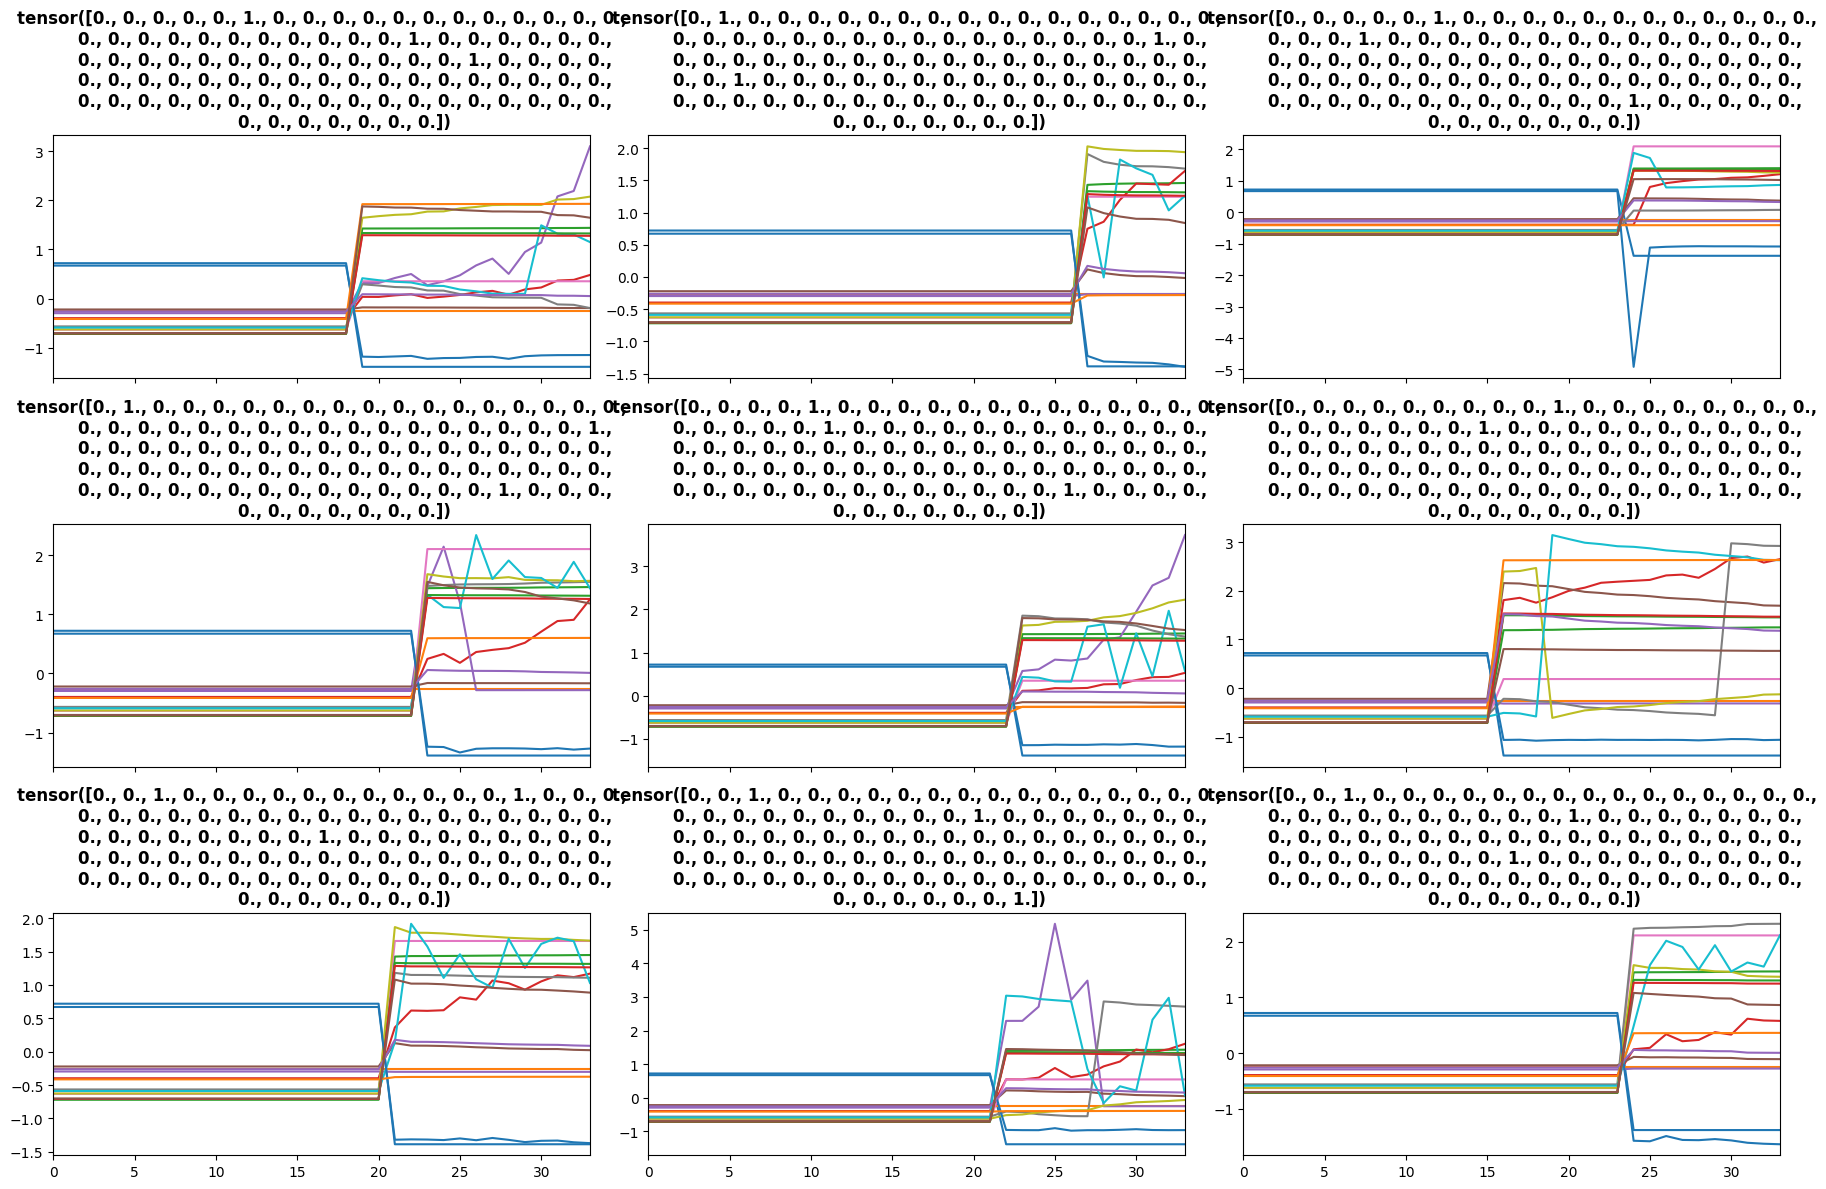

In [ ]:
learn.dls.show_batch()

wandb.finish()

In [ ]:
# learn.lr_find()

In [ ]:
learn.remove_cb(WandbCallback)

In [47]:
import numpy as np
import torch
print("--- PRUEBA DE PREDICCION (INFERENCIA) ---")

# 1. Elegimos una muestra del conjunto de VALIDACION real
indice_local_valid = 157  # posicion dentro de splits[1]
if indice_local_valid >= len(splits[1]):
    raise IndexError(f"indice_local_valid={indice_local_valid} fuera de rango. max={len(splits[1]) - 1}")

indice_prueba = splits[1][indice_local_valid]

# 2. Extraemos sus datos fisicos (X) y su respuesta real (y)
X_prueba = X_final[indice_prueba:indice_prueba+1]
y_real = y_final[indice_prueba]

# 3. Prediccion (logits crudos del modelo)
logits = learn.get_X_preds(X_prueba)[0][0].detach().cpu()

num_dias = sum(1 for c in classes if str(c).startswith('Dia_'))
num_horas = sum(1 for c in classes if str(c).startswith('Hora_'))
idx_horas = num_dias
idx_mins = num_dias + num_horas

# 4. Convertimos logits a probabilidades por bloque
probs_dias = torch.softmax(logits[:idx_horas], dim=0).numpy()
probs_horas = torch.softmax(logits[idx_horas:idx_mins], dim=0).numpy()
probs_mins = torch.softmax(logits[idx_mins:], dim=0).numpy()

clases_dias = classes[:idx_horas]
clases_horas = classes[idx_horas:idx_mins]
clases_mins = classes[idx_mins:]

pred_dia_idx = int(np.argmax(probs_dias))
pred_hora_idx = int(np.argmax(probs_horas))
pred_min_idx = int(np.argmax(probs_mins))

pred_dia = (clases_dias[pred_dia_idx], float(probs_dias[pred_dia_idx]))
pred_hora = (clases_horas[pred_hora_idx], float(probs_horas[pred_hora_idx]))
pred_min = (clases_mins[pred_min_idx], float(probs_mins[pred_min_idx]))

# 5. Ground truth
respuestas_reales = [classes[i] for i, valor in enumerate(y_real) if valor == 1]

print("\nREALIDAD (Ground Truth):")
print(f"Muestra global: {indice_prueba} | Posicion en validacion: {indice_local_valid}")
print(f"Clases reales: {respuestas_reales}")

print("\nPREDICCION DEL MODELO (PROBABILIDADES POR BLOQUE):")
print(f"DIA:    {pred_dia[0]:<10} (Confianza: {pred_dia[1]*100:.2f}%)")
print(f"HORA:   {pred_hora[0]:<10} (Confianza: {pred_hora[1]*100:.2f}%)")
print(f"MINUTO: {pred_min[0]:<10} (Confianza: {pred_min[1]*100:.2f}%)")

--- PRUEBA DE PREDICCION (INFERENCIA) ---



REALIDAD (Ground Truth):
Muestra global: 797 | Posicion en validacion: 157
Clases reales: ['Dia_11', 'Hora_18', 'Min_14']

PREDICCION DEL MODELO (PROBABILIDADES POR BLOQUE):
DIA:    Dia_13     (Confianza: 88.51%)
HORA:   Hora_19    (Confianza: 16.03%)
MINUTO: Min_7      (Confianza: 5.51%)


In [48]:
import torch

print("--- EVALUACION GLOBAL POST-ENTRENAMIENTO (CONJUNTO DE TRAIN) ---")

preds, targets = learn.get_preds(ds_idx=0)

num_dias = sum(1 for c in classes if str(c).startswith('Dia_'))
num_horas = sum(1 for c in classes if str(c).startswith('Hora_'))
idx_horas = num_dias
idx_mins = num_dias + num_horas

valid_mask = (
    (targets[:, :idx_horas].sum(dim=1) == 1)
    & (targets[:, idx_horas:idx_mins].sum(dim=1) == 1)
    & (targets[:, idx_mins:].sum(dim=1) == 1)
)

preds_v = preds[valid_mask]
targets_v = targets[valid_mask]
n_total = targets.shape[0]
n_valid = targets_v.shape[0]
n_invalid = n_total - n_valid

p_dias = preds_v[:, :idx_horas].argmax(dim=1)
p_horas = preds_v[:, idx_horas:idx_mins].argmax(dim=1)
p_mins = preds_v[:, idx_mins:].argmax(dim=1)

t_dias = targets_v[:, :idx_horas].argmax(dim=1)
t_horas = targets_v[:, idx_horas:idx_mins].argmax(dim=1)
t_mins = targets_v[:, idx_mins:].argmax(dim=1)

p_total = (p_dias.float() * 24.0) + p_horas.float() + (p_mins.float() / 60.0)
t_total = (t_dias.float() * 24.0) + t_horas.float() + (t_mins.float() / 60.0)

if n_valid > 0:
    mae_train = torch.abs(p_total - t_total).mean().item()
    mape_train = (torch.abs(p_total - t_total) / torch.clamp(torch.abs(t_total), min=(1.0 / 60.0))).mean().item() * 100

    aciertos_dia = int((p_dias == t_dias).sum().item())
    aciertos_hora = int((p_horas == t_horas).sum().item())
    aciertos_min = int((p_mins == t_mins).sum().item())

    acc_dia = aciertos_dia / n_valid
    acc_hora = aciertos_hora / n_valid
    acc_min = aciertos_min / n_valid
else:
    mae_train = float('nan')
    mape_train = float('nan')
    aciertos_dia = 0
    aciertos_hora = 0
    aciertos_min = 0
    acc_dia = float('nan')
    acc_hora = float('nan')
    acc_min = float('nan')

print("RESULTADOS TRAIN:")
print(f"- Filas totales evaluadas: {n_total}")
print(f"- Filas validas para comparacion: {n_valid}")
print(f"- Filas invalidas (target no one-hot por bloque): {n_invalid}")
print(f"- MAE global: {mae_train:.4f} horas")
print(f"- MAPE global: {mape_train:.4f}%")
print(f"- Acierto exacto Dia_X: {aciertos_dia}/{n_valid} ({acc_dia * 100:.2f}%)")
print(f"- Acierto exacto Hora_X: {aciertos_hora}/{n_valid} ({acc_hora * 100:.2f}%)")
print(f"- Acierto exacto Min_X: {aciertos_min}/{n_valid} ({acc_min * 100:.2f}%)")

--- EVALUACION GLOBAL POST-ENTRENAMIENTO (CONJUNTO DE TRAIN) ---


RESULTADOS TRAIN:
- Filas totales evaluadas: 640
- Filas validas para comparacion: 640
- Filas invalidas (target no one-hot por bloque): 0
- MAE global: 13.5084 horas
- MAPE global: 23.5378%
- Acierto exacto Dia_X: 468/640 (73.12%)
- Acierto exacto Hora_X: 93/640 (14.53%)
- Acierto exacto Min_X: 35/640 (5.47%)


In [49]:
import torch

print("--- EVALUACION GLOBAL POST-ENTRENAMIENTO (CONJUNTO DE VALIDACION) ---")

preds, targets = learn.get_preds(ds_idx=1)

num_dias = sum(1 for c in classes if str(c).startswith('Dia_'))
num_horas = sum(1 for c in classes if str(c).startswith('Hora_'))
idx_horas = num_dias
idx_mins = num_dias + num_horas

valid_mask = (
    (targets[:, :idx_horas].sum(dim=1) == 1)
    & (targets[:, idx_horas:idx_mins].sum(dim=1) == 1)
    & (targets[:, idx_mins:].sum(dim=1) == 1)
)

preds_v = preds[valid_mask]
targets_v = targets[valid_mask]
n_total = targets.shape[0]
n_valid = targets_v.shape[0]
n_invalid = n_total - n_valid

p_dias = preds_v[:, :idx_horas].argmax(dim=1)
p_horas = preds_v[:, idx_horas:idx_mins].argmax(dim=1)
p_mins = preds_v[:, idx_mins:].argmax(dim=1)

t_dias = targets_v[:, :idx_horas].argmax(dim=1)
t_horas = targets_v[:, idx_horas:idx_mins].argmax(dim=1)
t_mins = targets_v[:, idx_mins:].argmax(dim=1)

p_total = (p_dias.float() * 24.0) + p_horas.float() + (p_mins.float() / 60.0)
t_total = (t_dias.float() * 24.0) + t_horas.float() + (t_mins.float() / 60.0)

if n_valid > 0:
    mae_valid = torch.abs(p_total - t_total).mean().item()
    mape_valid = (torch.abs(p_total - t_total) / torch.clamp(torch.abs(t_total), min=(1.0 / 60.0))).mean().item() * 100

    aciertos_dia = int((p_dias == t_dias).sum().item())
    aciertos_hora = int((p_horas == t_horas).sum().item())
    aciertos_min = int((p_mins == t_mins).sum().item())

    acc_dia = aciertos_dia / n_valid
    acc_hora = aciertos_hora / n_valid
    acc_min = aciertos_min / n_valid
else:
    mae_valid = float('nan')
    mape_valid = float('nan')
    aciertos_dia = 0
    aciertos_hora = 0
    aciertos_min = 0
    acc_dia = float('nan')
    acc_hora = float('nan')
    acc_min = float('nan')

print("RESULTADOS VALIDACION:")
print(f"- Filas totales evaluadas: {n_total}")
print(f"- Filas validas para comparacion: {n_valid}")
print(f"- Filas invalidas (target no one-hot por bloque): {n_invalid}")
print(f"- MAE global: {mae_valid:.4f} horas")
print(f"- MAPE global: {mape_valid:.4f}%")
print(f"- Acierto exacto Dia_X: {aciertos_dia}/{n_valid} ({acc_dia * 100:.2f}%)")
print(f"- Acierto exacto Hora_X: {aciertos_hora}/{n_valid} ({acc_hora * 100:.2f}%)")
print(f"- Acierto exacto Min_X: {aciertos_min}/{n_valid} ({acc_min * 100:.2f}%)")

--- EVALUACION GLOBAL POST-ENTRENAMIENTO (CONJUNTO DE VALIDACION) ---


RESULTADOS VALIDACION:
- Filas totales evaluadas: 175
- Filas validas para comparacion: 175
- Filas invalidas (target no one-hot por bloque): 0
- MAE global: 41.8690 horas
- MAPE global: 47.6835%
- Acierto exacto Dia_X: 55/175 (31.43%)
- Acierto exacto Hora_X: 0/175 (0.00%)
- Acierto exacto Min_X: 4/175 (2.29%)


In [50]:
import pandas as pd
import numpy as np

print("--- COMPARATIVA MAPE: RPout vs NUESTRO MODELO ---")

# 1) Carga de RPout
rp = pd.read_csv('Datos/RPout.csv')
rp['TLEepoch'] = pd.to_datetime(rp['TLEepoch'], errors='coerce')
rp['ReentryEpoch'] = pd.to_datetime(rp['ReentryEpoch'], errors='coerce')

# 2) Ground truth por objeto usando el ultimo TIP
if 'last_tips' in globals() and {'NORAD_CAT_ID', 'DECAY_EPOCH'}.issubset(set(last_tips.columns)):
    gt = last_tips[['NORAD_CAT_ID', 'DECAY_EPOCH']].copy()
else:
    tip_aux = pd.read_csv('Datos/TIP.csv')
    tip_aux['MSG_EPOCH'] = pd.to_datetime(tip_aux['MSG_EPOCH'], dayfirst=True, errors='coerce')
    tip_aux['DECAY_EPOCH'] = pd.to_datetime(tip_aux['DECAY_EPOCH'], dayfirst=True, errors='coerce')
    tip_aux = tip_aux.sort_values(['NORAD_CAT_ID', 'MSG_EPOCH'])
    gt = tip_aux.groupby('NORAD_CAT_ID').last().reset_index()[['NORAD_CAT_ID', 'DECAY_EPOCH']]

# 3) Unir RPout con ground truth
df_cmp = rp.merge(gt, on='NORAD_CAT_ID', how='inner')

# 4) Calculo de TTE (horas) y APE
df_cmp['pred_tte_h'] = (df_cmp['ReentryEpoch'] - df_cmp['TLEepoch']).dt.total_seconds() / 3600.0
df_cmp['true_tte_h'] = (df_cmp['DECAY_EPOCH'] - df_cmp['TLEepoch']).dt.total_seconds() / 3600.0

mask_valid = (
    df_cmp['pred_tte_h'].notna()
    & df_cmp['true_tte_h'].notna()
    & np.isfinite(df_cmp['pred_tte_h'])
    & np.isfinite(df_cmp['true_tte_h'])
    & (df_cmp['true_tte_h'] > 0)
    & (df_cmp['pred_tte_h'] >= 0)
)

df_eval = df_cmp.loc[mask_valid].copy()

if len(df_eval) == 0:
    print('No hay filas validas para calcular MAPE en RPout con el cruce actual.')
else:
    df_eval['ape_pct'] = (np.abs(df_eval['pred_tte_h'] - df_eval['true_tte_h']) / np.clip(np.abs(df_eval['true_tte_h']), a_min=(1.0/60.0), a_max=None)) * 100.0
    mape_rpout = df_eval['ape_pct'].mean()

    norad_rpout = rp['NORAD_CAT_ID'].nunique()
    norad_gt = gt['NORAD_CAT_ID'].nunique()
    norad_comunes = df_cmp['NORAD_CAT_ID'].nunique()

    print('Cobertura del cruce:')
    print(f"- NORAD unicos en RPout: {norad_rpout}")
    print(f"- NORAD unicos en ground truth (TIP): {norad_gt}")
    print(f"- NORAD comunes: {norad_comunes}")

    print('\nFilas para evaluar RPout:')
    print(f"- Filas tras cruce (inner join): {len(df_cmp)}")
    print(f"- Filas validas para MAPE: {len(df_eval)}")

    print('\nMAPE RPout:')
    print(f"- MAPE global RPout: {mape_rpout:.4f}%")

    if 'mape_valid' in globals():
        print('\nComparativa con nuestro modelo (validacion):')
        print(f"- Nuestro MAPE validacion: {mape_valid:.4f}%")
        print(f"- RPout MAPE: {mape_rpout:.4f}%")
        print(f"- Diferencia (RPout - nuestro): {mape_rpout - mape_valid:.4f} puntos porcentuales")

    # Guardamos tabla por si quieres analizar luego
    cols_out = ['NORAD_CAT_ID', 'TLEepoch', 'ReentryEpoch', 'DECAY_EPOCH', 'pred_tte_h', 'true_tte_h', 'ape_pct']
    df_eval[cols_out].to_csv('datasets/rpout_mape_eval.csv', index=False)
    print("\nDetalle guardado en: datasets/rpout_mape_eval.csv")

--- COMPARATIVA MAPE: RPout vs NUESTRO MODELO ---
Cobertura del cruce:
- NORAD unicos en RPout: 67
- NORAD unicos en ground truth (TIP): 53
- NORAD comunes: 53

Filas para evaluar RPout:
- Filas tras cruce (inner join): 2255
- Filas validas para MAPE: 668

MAPE RPout:
- MAPE global RPout: 9.5213%

Comparativa con nuestro modelo (validacion):
- Nuestro MAPE validacion: 47.6835%
- RPout MAPE: 9.5213%
- Diferencia (RPout - nuestro): -38.1622 puntos porcentuales

Detalle guardado en: datasets/rpout_mape_eval.csv


In [53]:
import os
import pandas as pd
import numpy as np
import torch

print("--- COMPARATIVA JUSTA MAPE (MISMOS OBJETOS DE RPout) ---")

required_globals = ["learn", "classes", "splits", "sequence_metadata", "train_idx", "valid_idx"]
missing = [name for name in required_globals if name not in globals()]

# 1) RPout + ground truth
rp = pd.read_csv('Datos/RPout.csv')
required_rp_cols = {'NORAD_CAT_ID', 'TLEepoch', 'ReentryEpoch'}
missing_rp_cols = required_rp_cols - set(rp.columns)

if missing_rp_cols:
    print(f"❌ RPout no tiene columnas requeridas: {sorted(list(missing_rp_cols))}")
else:
    rp['NORAD_CAT_ID'] = pd.to_numeric(rp['NORAD_CAT_ID'], errors='coerce')
    rp['TLEepoch'] = pd.to_datetime(rp['TLEepoch'], errors='coerce')
    rp['ReentryEpoch'] = pd.to_datetime(rp['ReentryEpoch'], errors='coerce')

    if 'last_tips' in globals() and {'NORAD_CAT_ID', 'DECAY_EPOCH'}.issubset(set(last_tips.columns)):
        gt = last_tips[['NORAD_CAT_ID', 'DECAY_EPOCH']].copy()
    else:
        tip_aux = pd.read_csv('Datos/TIP.csv')
        tip_aux['MSG_EPOCH'] = pd.to_datetime(tip_aux['MSG_EPOCH'], dayfirst=True, errors='coerce')
        tip_aux['DECAY_EPOCH'] = pd.to_datetime(tip_aux['DECAY_EPOCH'], dayfirst=True, errors='coerce')
        tip_aux = tip_aux.sort_values(['NORAD_CAT_ID', 'MSG_EPOCH'])
        gt = tip_aux.groupby('NORAD_CAT_ID').last().reset_index()[['NORAD_CAT_ID', 'DECAY_EPOCH']]

    gt['NORAD_CAT_ID'] = pd.to_numeric(gt['NORAD_CAT_ID'], errors='coerce')
    gt['DECAY_EPOCH'] = pd.to_datetime(gt['DECAY_EPOCH'], errors='coerce')
    gt = gt.dropna(subset=['NORAD_CAT_ID', 'DECAY_EPOCH'])

    # Objetos presentes en RPout (predicciones del investigador)
    norad_rp_set = set(rp['NORAD_CAT_ID'].dropna().astype(int).unique().tolist())

    # MAPE del investigador
    df_cmp = rp.merge(gt, on='NORAD_CAT_ID', how='inner')
    df_cmp['pred_tte_h'] = (df_cmp['ReentryEpoch'] - df_cmp['TLEepoch']).dt.total_seconds() / 3600.0
    df_cmp['true_tte_h'] = (df_cmp['DECAY_EPOCH'] - df_cmp['TLEepoch']).dt.total_seconds() / 3600.0

    mask_rp_valid = (
        df_cmp['pred_tte_h'].notna()
        & df_cmp['true_tte_h'].notna()
        & np.isfinite(df_cmp['pred_tte_h'])
        & np.isfinite(df_cmp['true_tte_h'])
        & (df_cmp['true_tte_h'] > 0)
        & (df_cmp['pred_tte_h'] >= 0)
    )
    df_rp_eval = df_cmp.loc[mask_rp_valid].copy()

    if len(df_rp_eval) > 0:
        df_rp_eval['ape_pct'] = (
            np.abs(df_rp_eval['pred_tte_h'] - df_rp_eval['true_tte_h'])
            / np.clip(np.abs(df_rp_eval['true_tte_h']), a_min=(1.0 / 60.0), a_max=None)
        ) * 100.0
        mape_rpout = float(df_rp_eval['ape_pct'].mean())
    else:
        mape_rpout = float('nan')

    # 2) Nuestro MAPE en objetos de RPout
    seq_idx_order = np.concatenate([np.asarray(train_idx), np.asarray(valid_idx)])
    valid_global_idx = np.asarray(splits[1], dtype=int)
    valid_seq_idx = seq_idx_order[valid_global_idx]

    seq_meta_valid = sequence_metadata.iloc[valid_seq_idx].reset_index(drop=True)
    norad_valid_series = pd.to_numeric(seq_meta_valid['NORAD_CAT_ID'], errors='coerce')

    preds, targets = learn.get_preds(ds_idx=1)

    n_aligned = min(len(seq_meta_valid), preds.shape[0], targets.shape[0])
    if (len(seq_meta_valid) != preds.shape[0]) or (len(seq_meta_valid) != targets.shape[0]):
        print("⚠️ Aviso: longitudes no alineadas entre metadata y predicciones; se usa el minimo comun.")

    preds = preds[:n_aligned]
    targets = targets[:n_aligned]
    norad_valid_series = norad_valid_series.iloc[:n_aligned].reset_index(drop=True)

    num_dias = sum(1 for c in classes if str(c).startswith('Dia_'))
    num_horas = sum(1 for c in classes if str(c).startswith('Hora_'))
    idx_horas = num_dias
    idx_mins = num_dias + num_horas

    mask_onehot = (
        (targets[:, :idx_horas].sum(dim=1) == 1)
        & (targets[:, idx_horas:idx_mins].sum(dim=1) == 1)
        & (targets[:, idx_mins:].sum(dim=1) == 1)
    )

    mask_obj_rp = torch.as_tensor(norad_valid_series.isin(list(norad_rp_set)).to_numpy(), device=targets.device)
    mask_final = mask_onehot & mask_obj_rp

    p_dias = preds[:, :idx_horas].argmax(dim=1).float()
    p_horas = preds[:, idx_horas:idx_mins].argmax(dim=1).float()
    p_mins = preds[:, idx_mins:].argmax(dim=1).float()

    t_dias = targets[:, :idx_horas].argmax(dim=1).float()
    t_horas = targets[:, idx_horas:idx_mins].argmax(dim=1).float()
    t_mins = targets[:, idx_mins:].argmax(dim=1).float()

    p_total = (p_dias * 24.0) + p_horas + (p_mins / 60.0)
    t_total = (t_dias * 24.0) + t_horas + (t_mins / 60.0)

    if int(mask_final.sum().item()) > 0:
        p_eval = p_total[mask_final]
        t_eval = t_total[mask_final]
        mape_ours_rp = float(
            (torch.abs(p_eval - t_eval) / torch.clamp(torch.abs(t_eval), min=(1.0 / 60.0))).mean().item() * 100.0
        )
    else:
        mape_ours_rp = float('nan')

    # 3) Coberturas / confirmacion
    norad_ours_all = set(pd.to_numeric(sequence_metadata['NORAD_CAT_ID'], errors='coerce').dropna().astype(int).unique().tolist())
    norad_ours_valid = set(norad_valid_series.dropna().astype(int).unique().tolist())
    norad_common_valid = norad_ours_valid.intersection(norad_rp_set)
    norad_only_ours_valid = norad_ours_valid - norad_rp_set
    norad_only_rp = norad_rp_set - norad_ours_valid

    print("\n[1] Cobertura de objetos")
    print(f"- NORAD unicos en RPout (investigador): {len(norad_rp_set)}")
    print(f"- NORAD unicos en nuestro dataset completo: {len(norad_ours_all)}")
    print(f"- NORAD unicos en nuestra validacion: {len(norad_ours_valid)}")
    print(f"- NORAD comunes (RPout vs nuestra validacion): {len(norad_common_valid)}")
    print(f"- NORAD solo nuestros (en validacion, no en RPout): {len(norad_only_ours_valid)}")
    print(f"- NORAD solo RPout (no en nuestra validacion): {len(norad_only_rp)}")

    if len(norad_only_ours_valid) > 0:
        print("✅ Confirmado: tu validacion incluye objetos extra que no aparecen en RPout.")
    else:
        print("ℹ️ En validacion no se ven objetos extra frente a RPout.")

    print("\n[2] MAPE del investigador (RPout)")
    print(f"- Filas tras cruce RPout x TIP: {len(df_cmp)}")
    print(f"- Filas validas para MAPE RPout: {len(df_rp_eval)}")
    print(f"- MAPE RPout: {mape_rpout:.4f}%")

    print("\n[3] Nuestro MAPE restringido a objetos de RPout")
    print(f"- Filas de validacion totales (modelo): {n_aligned}")
    print(f"- Filas validas one-hot por bloque: {int(mask_onehot.sum().item())}")
    print(f"- Filas de objetos RPout dentro de validacion: {int(mask_obj_rp.sum().item())}")
    print(f"- Filas finales usadas (one-hot + objeto RPout): {int(mask_final.sum().item())}")
    print(f"- Nuestro MAPE (solo objetos RPout): {mape_ours_rp:.4f}%")

    if 'mape_valid' in globals():
        print("\n[4] Referencia contra tu MAPE global de validacion")
        print(f"- Tu MAPE global validacion (actual): {float(mape_valid):.4f}%")
        print(f"- Tu MAPE en objetos RPout: {mape_ours_rp:.4f}%")
        print(f"- Diferencia (restringido - global): {mape_ours_rp - float(mape_valid):.4f} pp")

    print("\n[5] Comparativa justa final (mismos objetos RPout)")
    print(f"- Investigador (RPout): {mape_rpout:.4f}%")
    print(f"- Nosotros (objetos RPout): {mape_ours_rp:.4f}%")
    print(f"- Diferencia (RPout - nosotros): {mape_rpout - mape_ours_rp:.4f} pp")

--- COMPARATIVA JUSTA MAPE (MISMOS OBJETOS DE RPout) ---



[1] Cobertura de objetos
- NORAD unicos en RPout (investigador): 67
- NORAD unicos en nuestro dataset completo: 52
- NORAD unicos en nuestra validacion: 11
- NORAD comunes (RPout vs nuestra validacion): 11
- NORAD solo nuestros (en validacion, no en RPout): 0
- NORAD solo RPout (no en nuestra validacion): 56
ℹ️ En validacion no se ven objetos extra frente a RPout.

[2] MAPE del investigador (RPout)
- Filas tras cruce RPout x TIP: 2255
- Filas validas para MAPE RPout: 668
- MAPE RPout: 9.5213%

[3] Nuestro MAPE restringido a objetos de RPout
- Filas de validacion totales (modelo): 175
- Filas validas one-hot por bloque: 175
- Filas de objetos RPout dentro de validacion: 175
- Filas finales usadas (one-hot + objeto RPout): 175
- Nuestro MAPE (solo objetos RPout): 47.6835%

[4] Referencia contra tu MAPE global de validacion
- Tu MAPE global validacion (actual): 47.6835%
- Tu MAPE en objetos RPout: 47.6835%
- Diferencia (restringido - global): 0.0000 pp

[5] Comparativa justa final (mismo